# Decentralised Solid Pod + Federated Learning — genuine in-Pod pipeline

This version makes three properties **real**, not simulated:

1. **Each local agent reads its participant's files from its own Pod** (not from a central store).
2. **Recommendations are written into the owner's Pod output directory.**
3. **Each client sends only aggregate `count/sum/sumsq`** to the aggregator, which combines them; the aggregator never sees raw features.

Config, `build_features`, and the recommendation trigger rules are unchanged, so the numeric results match the original.

## 1. Config

In [1]:
# ============================================================
# 1. CONFIG  ---  edit ONLY these two paths
# ============================================================
import os, json, warnings
from pathlib import Path
from collections import Counter
from datetime import datetime
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore")

PROJECT_PATH  = Path(r"C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation")
CSS_DATA_PATH = Path(r"C:\Users\Shabnam\SolidServer\data")

CLEAN_PATH = PROJECT_PATH / "01_cleaned_data"
OUTPUT_PATH   = PROJECT_PATH / "decentralised_solidpod_federated_workflow"
UPDATE_INBOX  = OUTPUT_PATH / "model_update_inbox"
GLOBAL_MODEL_PATH = OUTPUT_PATH / "global_model"
REPORT_PATH   = OUTPUT_PATH / "reports"
for p in [OUTPUT_PATH, UPDATE_INBOX, GLOBAL_MODEL_PATH, REPORT_PATH]:
    p.mkdir(parents=True, exist_ok=True)

# 5 PHYSICAL pods (security demo only) -- this is NEVER overwritten
POD_MAPPING = {
    "patient1": {"participant_id": "A4F_10021", "pod_folder_name": "patient1-1"},
    "patient2": {"participant_id": "A4F_10141", "pod_folder_name": "patient2"},
    "patient3": {"participant_id": "A4F_10355", "pod_folder_name": "patient3"},
    "patient4": {"participant_id": "A4F_10660", "pod_folder_name": "patient4"},
    "patient5": {"participant_id": "A4F_10709", "pod_folder_name": "patient5"},
}
def pod_input_path(patient):
    return CSS_DATA_PATH / POD_MAPPING[patient]["pod_folder_name"] / "dissertation" / "input"
def pod_output_path(patient):
    return CSS_DATA_PATH / POD_MAPPING[patient]["pod_folder_name"] / "dissertation" / "output"

RAW_FILES = {
    "meal_items":       "clean_ds3_meal_items.csv",
    "glucose":          "clean_ds4_glucose_all_participants.csv",
    "static_profile":   "clean_static_participant_profile.csv",
    "activity_daily":   "clean_ds7_activity_daily_merged.csv",
    "sleep_daily":      "clean_ds8_sleep_daily_merged.csv",
    "heart_rate_daily": "clean_ds6_heart_rate_daily.csv",
    "ecg_daily":        "clean_ds6_ecg_daily.csv",
    "emotion_daily":    "clean_ds9_emotional_daily_merged.csv",
}

TARGET = "glucose_60m"
MIN_MEALS = 10          # a participant needs >= this many usable meals to be a client

# fixed predictor set (same order for every client -- required for FedAvg)
STRONG = ["premeal_glucose","hour","day_of_week",
    "ts_glucose_t_minus_15m","ts_glucose_t_minus_30m","ts_glucose_t_minus_60m",
    "ts_glucose_mean_60m","ts_glucose_slope_60m","ts_glucose_std_60m",
    "ts_glucose_velocity_30m",
    "est_carbs_g","est_calories_kcal","est_protein_g","est_fat_g",
    "meal_item_count","sweets_count","fastfood_count","fruitveg_count",
    "age","bmi"]

print("Config OK. Physical pods:", list(POD_MAPPING.keys()))
print("Target:", TARGET, "| min meals:", MIN_MEALS)


Config OK. Physical pods: ['patient1', 'patient2', 'patient3', 'patient4', 'patient5']
Target: glucose_60m | min meals: 10


## 2. Helpers

In [2]:
# ---- helpers ----
def _mode_or_unknown(v):
    v=[x for x in v if pd.notna(x) and str(x).strip()!=""]
    return Counter(v).most_common(1)[0][0] if v else "Unknown"
def _dt(s): return pd.to_datetime(s, errors="coerce", utc=True)
def _sdiv(a,b): return np.nan if (pd.isna(a) or pd.isna(b) or b==0) else a/b
def _auc(t,v,base=None):
    v=np.asarray(v,float); t=np.asarray(t,float)
    if base is not None: v=v-base
    if len(v)<2: return np.nan
    _tp=getattr(np,"trapezoid",getattr(np,"trapz",None)); return _tp(v,t)
def _near_before(g,mt,mx=30):
    w=g[(g["timestamp"]<=mt)&(g["timestamp"]>=mt-pd.Timedelta(minutes=mx))]
    return None if w.empty else w.loc[(mt-w["timestamp"]).idxmin()]
def _near_after(g,mt,after=60,tol=20):
    tgt=mt+pd.Timedelta(minutes=after)
    w=g[(g["timestamp"]>=tgt-pd.Timedelta(minutes=tol))&(g["timestamp"]<=tgt+pd.Timedelta(minutes=tol))]
    return None if w.empty else w.loc[(w["timestamp"]-tgt).abs().idxmin()]
def _win_after(g,mt,end=120):
    return g[(g["timestamp"]>mt)&(g["timestamp"]<=mt+pd.Timedelta(minutes=end))].sort_values("timestamp")
def _near_gluc_before(g,mt,before,tol=12):
    tgt=mt-pd.Timedelta(minutes=before)
    w=g[(g["timestamp"]>=tgt-pd.Timedelta(minutes=tol))&(g["timestamp"]<=tgt+pd.Timedelta(minutes=tol))]
    return np.nan if w.empty else w.loc[(w["timestamp"]-tgt).abs().idxmin(),"glucose_value_in_mg_dl"]
def _win_stats(g,mt,before):
    w=g[(g["timestamp"]>=mt-pd.Timedelta(minutes=before))&(g["timestamp"]<=mt)]; k=before
    if w.empty:
        d={f"ts_glucose_{s}_{k}m":np.nan for s in ["mean","std","min","max","range","last","first","slope"]}
        d[f"ts_glucose_count_{k}m"]=0; return d
    v=w["glucose_value_in_mg_dl"].astype(float); fv,lv=v.iloc[0],v.iloc[-1]
    el=(w["timestamp"].iloc[-1]-w["timestamp"].iloc[0]).total_seconds()/60
    sl=(lv-fv)/el if el>0 else np.nan
    return {f"ts_glucose_count_{k}m":len(v),f"ts_glucose_mean_{k}m":v.mean(),f"ts_glucose_std_{k}m":v.std(),
            f"ts_glucose_min_{k}m":v.min(),f"ts_glucose_max_{k}m":v.max(),f"ts_glucose_range_{k}m":v.max()-v.min(),
            f"ts_glucose_last_{k}m":lv,f"ts_glucose_first_{k}m":fv,f"ts_glucose_slope_{k}m":sl}
def _cat_nutrition(cat,sub=None):
    txt=f"{str(cat).lower()} {str(sub).lower()}"
    tbl=[(["fast","burger","pizza","fries"],(350,650,70,25,30,"fast_food")),
         (["sweet","dessert","cake","chocolate","ice cream"],(180,450,60,5,18,"dessert")),
         (["beverage","drink","juice","soft drink"],(300,120,25,1,0,"beverage")),
         (["cereal","legume","bread","rice","pasta","potato"],(300,400,55,15,8,"cereal_legume")),
         (["fruit","vegetable","salad"],(250,150,25,4,2,"fruit_veg")),
         (["dairy","milk","yogurt"],(250,180,20,8,6,"dairy")),
         (["meat","fish","egg","chicken"],(250,350,5,35,18,"protein"))]
    for keys,(po,kc,ca,pr,ft,tag) in tbl:
        if any(k in txt for k in keys):
            return dict(estimated_portion_size_g=po,estimated_calories_kcal=kc,estimated_carbs_g=ca,
                        estimated_protein_g=pr,estimated_fat_g=ft,nutrition_estimation_source=f"category_{tag}_estimate")
    return dict(estimated_portion_size_g=250,estimated_calories_kcal=350,estimated_carbs_g=40,
                estimated_protein_g=12,estimated_fat_g=12,nutrition_estimation_source="category_generic_estimate")
def _existing(df,cands):
    for c in cands:
        if c in df.columns: return c
    return None
print("Helpers loaded.")


Helpers loaded.


## 3. Feature builder (one participant)

In [3]:
def build_features(participant_id, raw):
    """Full 03+04A pipeline for ONE participant from their own raw records."""
    pid=str(participant_id).strip()
    def own(df):
        if df is None or df.empty: return pd.DataFrame()
        df=df.copy()
        if "participant_id" in df.columns:
            df["participant_id"]=df["participant_id"].astype(str).str.strip()
            df=df[df["participant_id"]==pid]
        return df
    meal_items=own(raw.get("meal_items")); glucose=own(raw.get("glucose"))
    static_profile=own(raw.get("static_profile")); activity=own(raw.get("activity_daily"))
    sleep=own(raw.get("sleep_daily")); hr=own(raw.get("heart_rate_daily"))
    ecg=own(raw.get("ecg_daily")); emotion=own(raw.get("emotion_daily"))
    if meal_items.empty or glucose.empty: return pd.DataFrame()
    meal_items["meal_timestamp"]=_dt(meal_items["meal_timestamp"]); glucose["timestamp"]=_dt(glucose["timestamp"])
    meal_items=meal_items.dropna(subset=["meal_timestamp"])
    for c in ["category","subcategory","cooking_style"]:
        if c not in meal_items.columns: meal_items[c]="Unknown"
        meal_items[c]=meal_items[c].fillna("Unknown").astype(str)
    low=meal_items["category"].str.lower(); sub=meal_items["subcategory"].str.lower()
    meal_items["is_sweets"]=low.str.contains("sweet|dessert|cake|chocolate",na=False).astype(int)
    meal_items["is_snack"]=low.str.contains("snack",na=False).astype(int)
    meal_items["is_fastfood"]=low.str.contains("fast|burger|pizza|fries",na=False).astype(int)
    meal_items["is_fruitveg"]=low.str.contains("fruit|vegetable|salad",na=False).astype(int)
    meal_items["is_dairy"]=low.str.contains("dairy|milk|yogurt",na=False).astype(int)
    meal_items["is_bread_cereal"]=sub.str.contains("bread|cereal|rice|pasta|potato",na=False).astype(int)
    nut=pd.DataFrame(list(meal_items.apply(lambda r:_cat_nutrition(r["category"],r["subcategory"]),axis=1)))
    mi=pd.concat([meal_items.reset_index(drop=True),nut],axis=1)
    ev=(mi.groupby(["participant_id","id","meal_timestamp"],as_index=False)
        .agg(meal_item_count=("id","size"),unique_category_count=("category","nunique"),
             unique_subcategory_count=("subcategory","nunique"),dominant_category=("category",_mode_or_unknown),
             dominant_subcategory=("subcategory",_mode_or_unknown),dominant_cooking_style=("cooking_style",_mode_or_unknown),
             sweets_count=("is_sweets","sum"),snack_count=("is_snack","sum"),fastfood_count=("is_fastfood","sum"),
             fruitveg_count=("is_fruitveg","sum"),dairy_count=("is_dairy","sum"),bread_cereal_count=("is_bread_cereal","sum"),
             est_portion_size_g=("estimated_portion_size_g","sum"),est_calories_kcal=("estimated_calories_kcal","sum"),
             est_carbs_g=("estimated_carbs_g","sum"),est_protein_g=("estimated_protein_g","sum"),est_fat_g=("estimated_fat_g","sum")))
    gp=glucose.sort_values("timestamp"); mp=ev.sort_values("meal_timestamp"); recs=[]
    for _,m in mp.iterrows():
        mt=m["meal_timestamp"]; pre=_near_before(gp,mt,30); post=_win_after(gp,mt,120)
        if pre is None or post.shape[0]<3: continue
        base=float(pre["glucose_value_in_mg_dl"]); peak=post["glucose_value_in_mg_dl"].max()
        pkt=post.loc[post["glucose_value_in_mg_dl"].idxmax(),"timestamp"]
        g60=_near_after(gp,mt,60,20); g90=_near_after(gp,mt,90,20); g120=_near_after(gp,mt,120,25)
        offs=((post["timestamp"]-mt).dt.total_seconds()/60.0).values; r=m.to_dict()
        r.update({"date":mt.date(),"hour":mt.hour,"day_of_week":mt.dayofweek,"premeal_glucose":base,
            "glucose_60m":float(g60["glucose_value_in_mg_dl"]) if g60 is not None else np.nan,
            "glucose_90m":float(g90["glucose_value_in_mg_dl"]) if g90 is not None else np.nan,
            "glucose_120m":float(g120["glucose_value_in_mg_dl"]) if g120 is not None else np.nan,
            "peak_glucose_2h":peak,"peak_delay_min":(pkt-mt).total_seconds()/60.0,"delta_peak_2h":peak-base,
            "mean_glucose_2h":post["glucose_value_in_mg_dl"].mean(),
            "auc_2h":_auc(offs,post["glucose_value_in_mg_dl"].values,base)})
        recs.append(r)
    df=pd.DataFrame(recs)
    if df.empty: return df
    df["date"]=pd.to_datetime(df["date"]).dt.date
    if not static_profile.empty:
        sp=static_profile.loc[:,~static_profile.columns.duplicated()].drop_duplicates(subset=["participant_id"])
        df=df.merge(sp,on="participant_id",how="left",suffixes=("","_static"))
    for name,src in [("sleep",sleep),("activity",activity),("heart_rate_daily",hr),("ecg_daily",ecg),("emotion_daily",emotion)]:
        if src.empty or "date" not in src.columns: continue
        t=src.copy(); t["date"]=pd.to_datetime(t["date"],errors="coerce").dt.date
        cols=[c for c in t.columns if c not in ["participant_id","date"]]
        t[f"{name}_available"]=t[cols].notna().any(axis=1).astype(int)
        t=t.rename(columns={c:f"{name}_{c}" for c in cols})
        df=df.merge(t,on=["participant_id","date"],how="left")
    lags=[15,30,45,60,90,120]; wins=[30,60,90,120]; ts=[]
    for _,m in df.sort_values("meal_timestamp").iterrows():
        mt=m["meal_timestamp"]; row={"participant_id":pid,"meal_timestamp":mt}
        for lg in lags: row[f"ts_glucose_t_minus_{lg}m"]=_near_gluc_before(gp,mt,lg,12)
        pm=m.get("premeal_glucose",np.nan)
        for lg in lags:
            lv=row[f"ts_glucose_t_minus_{lg}m"]
            row[f"ts_delta_premeal_minus_{lg}m"]=(pm-lv) if pd.notna(pm) and pd.notna(lv) else np.nan
        for w in wins: row.update(_win_stats(gp,mt,w))
        g15,g30,g60=row.get("ts_glucose_t_minus_15m"),row.get("ts_glucose_t_minus_30m"),row.get("ts_glucose_t_minus_60m")
        row["ts_glucose_velocity_15m"]=_sdiv(pm-g15,15); row["ts_glucose_velocity_30m"]=_sdiv(pm-g30,30)
        row["ts_glucose_velocity_60m"]=_sdiv(pm-g60,60)
        v15,v30=row["ts_glucose_velocity_15m"],row["ts_glucose_velocity_30m"]
        row["ts_glucose_acceleration_30m"]=(v15-v30) if pd.notna(v15) and pd.notna(v30) else np.nan
        ts.append(row)
    df=df.merge(pd.DataFrame(ts),on=["participant_id","meal_timestamp"],how="left")
    df=df.sort_values("meal_timestamp").reset_index(drop=True)
    return df
print("build_features() ready.")


build_features() ready.


## 4. Load cleaned data

In [4]:
raw_all={}
for key,fname in RAW_FILES.items():
    p=CLEAN_PATH/fname
    raw_all[key]=pd.read_csv(p) if p.exists() else pd.DataFrame()
    print(f"{key:18s}: {'MISSING' if raw_all[key].empty else raw_all[key].shape}")


meal_items        : (9168, 9)
glucose           : (104196, 16)
static_profile    : (96, 174)
activity_daily    : (1545, 49)
sleep_daily       : (1465, 46)
heart_rate_daily  : (1549, 3)
ecg_daily         : (1185, 3)
emotion_daily     : (1152, 10)


## 5. Distribute raw records into the 5 PHYSICAL pods (security demo, unchanged)

In [5]:
dist_rows=[]
for patient,info in POD_MAPPING.items():
    pid=info["participant_id"]; pin=pod_input_path(patient); pin.mkdir(parents=True,exist_ok=True)
    pod_output_path(patient).mkdir(parents=True,exist_ok=True)
    written=0
    for key,df in raw_all.items():
        if df.empty or "participant_id" not in df.columns: continue
        own=df[df["participant_id"].astype(str).str.strip()==pid]
        own.to_csv(pin/f"{key}.csv",index=False); written+=len(own)
    dist_rows.append({"patient":patient,"participant_id":pid,"rows_written":written})
dist_df=pd.DataFrame(dist_rows); dist_df.to_csv(REPORT_PATH/"raw_data_distribution.csv",index=False)
display(dist_df)


,patient,participant_id,rows_written
0,patient1,A4F_10021,947
1,patient2,A4F_10141,1073
2,patient3,A4F_10355,1183
3,patient4,A4F_10660,1337
4,patient5,A4F_10709,1396


## 6. Provision a logical Pod for EVERY eligible client
Each participant gets their own Pod directory (`input/` + `output/`) containing only their own raw tables. From here on, feature engineering reads from the Pod, so data locality is enforced per client, not just for the 5 physical pods.

In [6]:
# One Solid-style Pod per eligible participant.
LOGICAL_PODS_ROOT = OUTPUT_PATH / "logical_pods"
LOGICAL_PODS_ROOT.mkdir(parents=True, exist_ok=True)

def logical_pod_input(pid):  return LOGICAL_PODS_ROOT / str(pid) / "input"
def logical_pod_output(pid): return LOGICAL_PODS_ROOT / str(pid) / "output"

src = raw_all["meal_items"].copy()
src["participant_id"] = src["participant_id"].astype(str).str.strip()
counts = src["participant_id"].value_counts()
eligible = counts[counts >= MIN_MEALS].index.tolist()

provisioned = 0
for pid in eligible:
    pin = logical_pod_input(pid); pin.mkdir(parents=True, exist_ok=True)
    logical_pod_output(pid).mkdir(parents=True, exist_ok=True)
    for key, df in raw_all.items():
        if df.empty:
            continue
        if "participant_id" in df.columns:
            own = df[df["participant_id"].astype(str).str.strip() == str(pid)]
        else:
            own = df.head(0)          # nothing participant-specific to place
        own.to_csv(pin / f"{key}.csv", index=False)
    provisioned += 1
print(f"Provisioned {provisioned} logical Pods under {LOGICAL_PODS_ROOT}")
print("Eligible clients (>= {} meals): {}".format(MIN_MEALS, len(eligible)))

Provisioned 95 logical Pods under C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\logical_pods
Eligible clients (>= 10 meals): 95


## 7. Security model — agent reads/writes ONLY its own Pod; aggregator sees only aggregates

In [7]:
class LocalSolidPodAgent:
    """Acts for ONE participant. May read/write only that participant's Pod."""
    def __init__(self, participant_id):
        self.participant_id = str(participant_id)
        self.in_dir  = logical_pod_input(self.participant_id).resolve()
        self.out_dir = logical_pod_output(self.participant_id).resolve()
        self.out_dir.mkdir(parents=True, exist_ok=True)

    def _authorise(self, path):
        path = Path(path).resolve()
        ok = str(path).startswith(str(self.in_dir)) or str(path).startswith(str(self.out_dir))
        if not ok:
            raise PermissionError(
                f"ACCESS DENIED: agent for {self.participant_id} may access only its own Pod")
        return path

    def read_table(self, key):
        f = self._authorise(self.in_dir / f"{key}.csv")
        return pd.read_csv(f) if f.exists() else pd.DataFrame()

    def read_all_raw(self):
        return {key: self.read_table(key) for key in RAW_FILES}

    def build_local_features(self):
        # Feature engineering runs on data the agent reads FROM ITS OWN POD.
        return build_features(self.participant_id, self.read_all_raw())

    def local_standardisation_stats(self, X):
        # Only these three aggregates ever leave the client.
        X = np.asarray(X, float)
        return {"pid": self.participant_id, "n": int(len(X)),
                "sum": X.sum(0), "sumsq": (X ** 2).sum(0)}

    def write_output(self, filename, df):
        path = self._authorise(self.out_dir / filename)
        df.to_csv(path, index=False)
        return path


class FederatedAggregator:
    """Receives only model updates and aggregate statistics. Never reads raw Pod data."""
    def __init__(self, inbox):
        self.inbox = Path(inbox).resolve(); self.inbox.mkdir(parents=True, exist_ok=True)

    def combine_standardisation(self, client_stats):
        # client_stats: list of {n, sum, sumsq} -- NO raw rows are passed here.
        tot_n  = sum(s["n"] for s in client_stats)
        tot_sum = np.sum([s["sum"]   for s in client_stats], axis=0)
        tot_sq  = np.sum([s["sumsq"] for s in client_stats], axis=0)
        mean = tot_sum / tot_n
        std  = np.sqrt(np.maximum(tot_sq / tot_n - mean ** 2, 1e-8))
        return mean, std

    def weighted_fedavg(self, updates):
        # updates: list of {w, b, n}. Only weights + counts, never raw data.
        total = sum(u["n"] for u in updates)
        w = np.sum([(u["n"] / total) * u["w"] for u in updates], axis=0)
        b = float(np.sum([(u["n"] / total) * u["b"] for u in updates]))
        return w, b

    def read_model_updates(self):
        return [json.load(open(f, encoding="utf-8"))
                for f in sorted(self.inbox.glob("client_update_*.json"))]

    def read_pod_raw_data(self, *a, **k):
        raise PermissionError("ACCESS DENIED: aggregator cannot read raw Solid Pod data.")

print("Security model ready (genuine per-Pod read/write + aggregate-only aggregator).")

Security model ready (genuine per-Pod read/write + aggregate-only aggregator).


## 8. Each client reads its Pod, builds features locally, and prepares its split

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

ROUNDS, LOCAL_EPOCHS, LR, L2 = 30, 5, 0.05, 1e-4

def local_gd(w, b, Xs, y, epochs, lr, l2):
    n = len(y)
    for _ in range(epochs):
        err = (Xs @ w + b) - y
        w = w - lr * ((2.0/n) * (Xs.T @ err) + 2.0*l2*w)
        b = b - lr * ((2.0/n) * err.sum())
    return w, b

# fix the shared feature order once (FedAvg needs identical features across clients)
_ref_agent = LocalSolidPodAgent(eligible[0])
ref = _ref_agent.build_local_features()
FEATURES = [c for c in STRONG if c in ref.columns]
if len(FEATURES) < 5:
    LEAK = {TARGET,"glucose_90m","glucose_120m","peak_glucose_2h","delta_peak_2h",
            "auc_2h","mean_glucose_2h","peak_delay_min"}
    FEATURES = [c for c in ref.select_dtypes(include=[np.number]).columns if c not in LEAK][:20]
print("Shared features ({}):".format(len(FEATURES)), FEATURES)

clients, log = [], []
for i, pid in enumerate(eligible):
    agent = LocalSolidPodAgent(pid)               # <-- one agent per client
    feats = agent.build_local_features()          # <-- reads ITS OWN Pod, not raw_all
    if feats.empty or TARGET not in feats.columns:
        log.append({"client": f"client_{i+1}", "pid": pid, "status": "no_features"}); continue
    d = feats[FEATURES+[TARGET]].replace([np.inf,-np.inf], np.nan).dropna(subset=[TARGET])
    if len(d) < MIN_MEALS:
        log.append({"client": f"client_{i+1}", "pid": pid, "status": "too_few_rows"}); continue
    X = d[FEATURES].fillna(d[FEATURES].median(numeric_only=True)).fillna(0.0).astype(float).values
    y = d[TARGET].astype(float).values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=42)
    clients.append({"pid": pid, "agent": agent, "Xtr": Xtr, "ytr": ytr, "Xte": Xte, "yte": yte})
    log.append({"client": f"client_{i+1}", "pid": pid, "status": "trained"})

log_df = pd.DataFrame(log)
print("eligible:", len(eligible), "| trained:", len(clients),
      "| missing:", len(eligible) - len(clients))

Shared features (20): ['premeal_glucose', 'hour', 'day_of_week', 'ts_glucose_t_minus_15m', 'ts_glucose_t_minus_30m', 'ts_glucose_t_minus_60m', 'ts_glucose_mean_60m', 'ts_glucose_slope_60m', 'ts_glucose_std_60m', 'ts_glucose_velocity_30m', 'est_carbs_g', 'est_calories_kcal', 'est_protein_g', 'est_fat_g', 'meal_item_count', 'sweets_count', 'fastfood_count', 'fruitveg_count', 'age', 'bmi']
eligible: 95 | trained: 90 | missing: 5


## 9. Federated standardisation — clients send only `{n, sum, sumsq}`
The aggregator computes the global mean/std from client-supplied aggregates. It never touches any client's `Xtr`.

In [9]:
agg = FederatedAggregator(UPDATE_INBOX)

# Each client computes its OWN aggregates and sends only those three arrays.
client_stats = [c["agent"].local_standardisation_stats(c["Xtr"]) for c in clients]

# Aggregator combines aggregates -> global mean/std (no raw features seen here).
g_mean, g_std = agg.combine_standardisation(client_stats)

def std(X): return (np.asarray(X, float) - g_mean) / g_std

# Each client standardises locally with the received global stats.
for c in clients:
    c["_Xs"] = std(c["Xtr"]); c["_n"] = len(c["ytr"])

Xte_all = np.vstack([std(c["Xte"]) for c in clients])
yte_all = np.concatenate([c["yte"] for c in clients])
print("Federated standardisation done from aggregates only. Global mean[0]=%.3f std[0]=%.3f"
      % (g_mean[0], g_std[0]))

Federated standardisation done from aggregates only. Global mean[0]=101.555 std[0]=16.500


## 10. Multi-round FedAvg — only weights leave each Pod

In [10]:
D = len(FEATURES); w = np.zeros(D); b = 0.0
history = []
for r in range(1, ROUNDS+1):
    updates = []
    for c in clients:                                   # each client trains locally
        cw, cb = local_gd(w.copy(), b, c["_Xs"], c["ytr"], LOCAL_EPOCHS, LR, L2)
        updates.append({"w": cw, "b": cb, "n": c["_n"]})  # only weights + count leave
    w, b = agg.weighted_fedavg(updates)                 # aggregator averages weights
    yhat = Xte_all @ w + b
    history.append({"round": r,
                    "R2":  round(r2_score(yte_all, yhat), 4),
                    "MAE": round(mean_absolute_error(yte_all, yhat), 3),
                    "RMSE":round(mean_squared_error(yte_all, yhat)**0.5, 3)})
hist_df = pd.DataFrame(history); hist_df.to_csv(REPORT_PATH/"fedavg_learning_curve.csv", index=False)

# save global model + weight-only client update files (for the access-control audit)
global_model = {"model_type":"Multi-round FedAvg (linear)","target":TARGET,"features":FEATURES,
    "coef":w.tolist(),"intercept":float(b),"scaler_mean":g_mean.tolist(),"scaler_std":g_std.tolist(),
    "rounds":ROUNDS,"local_epochs":LOCAL_EPOCHS,"n_clients":len(clients)}
json.dump(global_model, open(GLOBAL_MODEL_PATH/"global_federated_model.json","w"), indent=2)
for old in UPDATE_INBOX.glob("client_update_*.json"): old.unlink()
for c in clients:
    cw, cb = local_gd(w.copy(), b, c["_Xs"], c["ytr"], LOCAL_EPOCHS, LR, L2)
    json.dump({"participant_id":c["pid"],"target":TARGET,"features":FEATURES,
               "coef":cw.tolist(),"intercept":float(cb),"n_train":int(c["_n"])},
              open(UPDATE_INBOX/f"client_update_{c['pid']}.json","w"), indent=2)
print(f"Rounds: {ROUNDS} | final federated R2 = {history[-1]['R2']}  MAE = {history[-1]['MAE']}")
display(hist_df.iloc[[0,4,9,19,-1]])

Rounds: 30 | final federated R2 = 0.1909  MAE = 15.616


,round,R2,MAE,RMSE
0,1,-15.0786,88.646,91.410
4,5,-2.0661,34.026,39.918
9,10,-0.0876,17.869,23.774
19,20,0.1756,15.677,20.698
29,30,0.1909,15.616,20.506


## 11. Centralised baseline (non-private reference, pools data) + comparison

In [11]:
import matplotlib.pyplot as plt
Xtr_all = np.vstack([c["Xtr"] for c in clients]); ytr_all = np.concatenate([c["ytr"] for c in clients])
cmean = Xtr_all.mean(0); cstd = np.maximum(Xtr_all.std(0), 1e-8)
cw = np.zeros(len(FEATURES)); cb = 0.0
cw, cb = local_gd(cw, cb, (Xtr_all-cmean)/cstd, ytr_all, 300, LR, L2)
Xte_raw = np.vstack([c["Xte"] for c in clients])
yhat_cen = ((Xte_raw-cmean)/cstd) @ cw + cb
cen = {"R2":round(r2_score(yte_all,yhat_cen),4),"MAE":round(mean_absolute_error(yte_all,yhat_cen),3),
       "RMSE":round(mean_squared_error(yte_all,yhat_cen)**0.5,3)}
results = pd.DataFrame([
    {"approach":"Federated (multi-round FedAvg)", **history[-1]},
    {"approach":"Centralised (pooled, same features)","round":"-", **cen},
])
results.to_csv(REPORT_PATH/"federated_vs_centralised.csv", index=False)
display(results)

,approach,round,R2,MAE,RMSE
0,Federated (multi-round FedAvg),30,0.1909,15.616,20.506
1,"Centralised (pooled, same features)",-,0.2048,15.495,20.329


## 11b. Reference models, baselines, and multi-seed robustness
These reconstruct the analyses from the lost notebook. They reuse the objects built above (`clients`, `local_gd`, `agg`, `std`, `Xte_all`, `yte_all`, `history`, `cen`). **Verify the printed numbers against your dissertation and update the text to whatever these actually produce.**

In [15]:
# --- Multi-seed robustness: re-split + re-train federated and centralised across seeds ---
import math
SEEDS = [0, 1, 2, 3, 4]     # adjust if you used different seeds
full = [{"X": np.vstack([c["Xtr"], c["Xte"]]), "y": np.concatenate([c["ytr"], c["yte"]])} for c in clients]
fed_scores, cen_scores = [], []
for seed in SEEDS:
    parts = []
    for f in full:
        Xtr, Xte, ytr, yte = train_test_split(f["X"], f["y"], test_size=0.25, random_state=seed)
        parts.append({"Xtr":Xtr,"Xte":Xte,"ytr":ytr,"yte":yte})
    stats = [{"n":len(p["Xtr"]), "sum":p["Xtr"].sum(0), "sumsq":(p["Xtr"]**2).sum(0)} for p in parts]
    gm, gs = agg.combine_standardisation(stats)
    def _s(X): return (X - gm) / gs
    Xte_a = np.vstack([_s(p["Xte"]) for p in parts]); yte_a = np.concatenate([p["yte"] for p in parts])
    w = np.zeros(D); b = 0.0
    for _ in range(ROUNDS):
        ups = [{"w":local_gd(w.copy(), b, _s(p["Xtr"]), p["ytr"], LOCAL_EPOCHS, LR, L2)[0],
                "b":local_gd(w.copy(), b, _s(p["Xtr"]), p["ytr"], LOCAL_EPOCHS, LR, L2)[1],
                "n":len(p["ytr"])} for p in parts]
        w, b = agg.weighted_fedavg(ups)
    fed_scores.append(r2_score(yte_a, Xte_a @ w + b))
    Xtr_all = np.vstack([p["Xtr"] for p in parts]); ytr_all = np.concatenate([p["ytr"] for p in parts])
    cm = Xtr_all.mean(0); cs = np.maximum(Xtr_all.std(0), 1e-8)
    cw, cb = local_gd(np.zeros(D), 0.0, (Xtr_all-cm)/cs, ytr_all, 300, LR, L2)
    Xte_raw = np.vstack([p["Xte"] for p in parts])
    cen_scores.append(r2_score(yte_a, ((Xte_raw-cm)/cs) @ cw + cb))
fed_scores = np.array(fed_scores); cen_scores = np.array(cen_scores); gap = cen_scores - fed_scores
ci95 = 1.96 * gap.std(ddof=1) / math.sqrt(len(gap))
multiseed = {"fed_mean":round(fed_scores.mean(),3), "fed_sd":round(fed_scores.std(ddof=1),3),
             "cen_mean":round(cen_scores.mean(),3), "cen_sd":round(cen_scores.std(ddof=1),3),
             "gap_mean":round(gap.mean(),3), "gap_ci95":round(ci95,3), "seeds":SEEDS}
print("Multi-seed  federated R2 %.3f (SD %.3f) | centralised %.3f (SD %.3f) | gap %.3f (95%% CI +/- %.3f)"
      % (multiseed["fed_mean"], multiseed["fed_sd"], multiseed["cen_mean"], multiseed["cen_sd"],
         multiseed["gap_mean"], multiseed["gap_ci95"]))
print("(paper reported: fed 0.177 SD 0.014, cen 0.189 SD 0.010, gap 0.012 CI +/-0.003)")

Multi-seed  federated R2 0.166 (SD 0.006) | centralised 0.179 (SD 0.009) | gap 0.013 (95% CI +/- 0.006)
(paper reported: fed 0.177 SD 0.014, cen 0.189 SD 0.010, gap 0.012 CI +/-0.003)


In [16]:
# --- Assemble the results tables (paper Table 4.2 + baselines table) ---
table42 = pd.DataFrame([
    {"Model":"Federated (multi-round FedAvg, 30 rounds)", "R2":history[-1]["R2"], "MAE":history[-1]["MAE"], "RMSE":history[-1]["RMSE"]},
    {"Model":"Federated (single-round, one-shot)",        **single_round},
    {"Model":"Centralised (pooled, same features)",       **cen},
    {"Model":f"Centralised ({xgb_ref['model']}, full features)*", "R2":xgb_ref["R2"], "MAE":xgb_ref["MAE"], "RMSE":xgb_ref["RMSE"]},
])
table42.to_csv(REPORT_PATH/"table_4_2_utility.csv", index=False)
print("TABLE 4.2 — Federated vs centralised utility"); display(table42)

baselines = pd.DataFrame([
    {"Baseline":"Mean prediction",               **mean_base},
    {"Baseline":"Local-only (no collaboration)", **local_only},
    {"Baseline":"Federated (multi-round)",       "R2":history[-1]["R2"], "MAE":history[-1]["MAE"], "RMSE":history[-1]["RMSE"]},
    {"Baseline":"Centralised (pooled)",          **cen},
])
baselines.to_csv(REPORT_PATH/"table_baselines.csv", index=False)
print("BASELINES — does federation beat non-collaborative learning?"); display(baselines)

TABLE 4.2 — Federated vs centralised utility


,Model,R2,MAE,RMSE
0,"Federated (multi-round FedAvg, 30 rounds)",1.909000e-01,1.561600e+01,2.050600e+01
1,"Federated (single-round, one-shot)",-1.410062e+47,6.822756e+24,8.560311e+24
2,"Centralised (pooled, same features)",2.048000e-01,1.549500e+01,2.032900e+01
3,"Centralised (XGBoost, full features)*",6.047000e-01,1.008000e+01,1.445400e+01


BASELINES — does federation beat non-collaborative learning?


,Baseline,R2,MAE,RMSE
0,Mean prediction,-0.0002,17.603,22.799
1,Local-only (no collaboration),0.3254,13.076,18.723
2,Federated (multi-round),0.1909,15.616,20.506
3,Centralised (pooled),0.2048,15.495,20.329


## 12. In-Pod recommendations — written into each owner's Pod output directory

In [17]:
def _detect(g60, premeal, carbs, calories, protein):
    T=[]
    def add(n,s,r,rec): T.append({"trigger":n,"severity":s,"reason":r,"recommendation":rec})
    if pd.notna(g60):
        if g60>=180: add("high_predicted_glucose",5,f"Predicted 60-min glucose high at {g60:.1f} mg/dL.","Check glucose within 60 min; avoid extra carbs for 2 hours.")
        elif g60>=140: add("moderate_predicted_glucose",3,f"Predicted 60-min glucose moderately elevated at {g60:.1f} mg/dL.","Re-check glucose in 60-90 min; avoid sugary snacks.")
        else: add("stable_predicted_glucose",0,f"Predicted 60-min glucose within range at {g60:.1f} mg/dL.","Continue routine monitoring.")
    if pd.notna(g60) and pd.notna(premeal):
        rise=g60-premeal
        if rise>=50: add("large_predicted_rise",4,f"Predicted rise large at {rise:.1f} mg/dL.","Consider a 15-20 min gentle walk if safe.")
        elif rise>=30: add("moderate_predicted_rise",2,f"Predicted rise moderate at {rise:.1f} mg/dL.","A short 10-15 min walk may help.")
    if pd.notna(carbs):
        if carbs>=70: add("high_carbohydrate_meal",4,f"Carbohydrate high at {carbs:.1f} g.","Reduce carb portion; pair carbs with protein or fibre.")
        elif carbs>=45: add("moderate_carbohydrate_meal",2,f"Carbohydrate moderate at {carbs:.1f} g.","Monitor portion size for similar meals.")
    if pd.notna(calories) and calories>=700: add("high_calorie_meal",2,f"Calories high at {calories:.1f} kcal.","Consider reducing portion size.")
    if pd.notna(protein) and pd.notna(carbs) and carbs>=45 and protein<10: add("low_protein_high_carb",2,"Carb-heavy, low protein.","Add a protein source to reduce glycaemic impact.")
    return T

def _decision(g60,premeal,carbs,cal,prot):
    t=_detect(g60,premeal,carbs,cal,prot)
    if not t: return {"primary_trigger":"routine_monitoring","support_level":"Routine support","support_score":0,"reasoning":"No strong risk triggers detected.","recommendations":["Maintain routine; continue monitoring."]}
    t.sort(key=lambda x:x["severity"],reverse=True)
    score=int(sum(x["severity"] for x in t))
    level="High support needed" if score>=8 else "Moderate support needed" if score>=3 else "Routine support"
    recs=[]
    for x in t:
        if x["recommendation"] not in recs: recs.append(x["recommendation"])
    reason=f"Assigned {level}; primary trigger '{t[0]['trigger']}'. Federated model predicted 60-min glucose {('unavailable' if pd.isna(g60) else f'{g60:.1f} mg/dL')}."
    return {"primary_trigger":t[0]["trigger"],"support_level":level,"support_score":score,"reasoning":reason,"recommendations":recs}

def _sn(v):
    try: return np.nan if pd.isna(v) else float(v)
    except: return np.nan

gmean=np.array(global_model["scaler_mean"]); gstd=np.array(global_model["scaler_std"]); gstd[gstd==0]=1.0
gcoef=np.array(global_model["coef"]); gint=global_model["intercept"]

summary=[]
for pid in eligible:
    agent = LocalSolidPodAgent(pid)                 # the owner's agent
    feats = agent.build_local_features()            # reads ITS OWN Pod
    if feats.empty: continue
    X=feats[FEATURES].fillna(feats[FEATURES].median(numeric_only=True)).fillna(0.0).astype(float).values
    g60=((X-gmean)/gstd)@gcoef+gint                 # federated prediction, computed in-Pod
    recs=[]
    for i in range(len(feats)):
        r=feats.iloc[i]
        d=_decision(g60[i],_sn(r.get("premeal_glucose")),_sn(r.get("est_carbs_g")),_sn(r.get("est_calories_kcal")),_sn(r.get("est_protein_g")))
        recs.append({"meal_timestamp":str(r.get("meal_timestamp")),"predicted_glucose_60m":round(float(g60[i]),1),
                     "primary_trigger":d["primary_trigger"],"support_level":d["support_level"],
                     "support_score":d["support_score"],"reasoning":d["reasoning"],
                     "recommendations":" | ".join(d["recommendations"])})
    rec_df=pd.DataFrame(recs)
    agent.write_output(f"recommendations_{pid}.csv", rec_df)   # <-- written INTO the owner's Pod output
    vc=rec_df["support_level"].value_counts()
    summary.append({"participant_id":pid,"meals":len(rec_df),
                    "High":int(vc.get("High support needed",0)),
                    "Moderate":int(vc.get("Moderate support needed",0)),
                    "Routine":int(vc.get("Routine support",0))})

summary_df=pd.DataFrame(summary)
summary_df.to_csv(REPORT_PATH/"recommendation_summary.csv", index=False)
tot=summary_df[["High","Moderate","Routine"]].sum()
print("In-Pod recommendations generated for", len(summary_df), "clients")
print("Support-level distribution:", tot.to_dict())
print("participants with any Moderate+:", int((summary_df["Moderate"]+summary_df["High"]>0).sum()))
display(summary_df.head(10))

In-Pod recommendations generated for 95 clients
Support-level distribution: {'High': 0, 'Moderate': 663, 'Routine': 7805}
participants with any Moderate+: 85


,participant_id,meals,High,Moderate,Routine
0,A4F_20573,234,0,35,199
1,A4F_29474,216,0,21,195
2,A4F_50227,168,0,7,161
3,A4F_40008,150,0,9,141
4,A4F_76292,179,0,11,168
5,A4F_73455,108,0,23,85
6,A4F_17419,175,0,30,145
7,A4F_89897,152,0,9,143
8,A4F_78358,160,0,16,144
9,A4F_60728,120,0,22,98


## 13. Access-control verification (agents + aggregator + update audit)

In [18]:
checks=[]
# 1) an agent may read its own Pod
try:
    a=LocalSolidPodAgent(eligible[0]); _=a.read_table("glucose")
    checks.append({"test":f"{eligible[0]} reads own pod","expected":"Allowed","actual":"Allowed","passed":True})
except Exception as e:
    checks.append({"test":f"{eligible[0]} reads own pod","expected":"Allowed","actual":"Denied","passed":False})
# 2) an agent may NOT read another Pod
try:
    a=LocalSolidPodAgent(eligible[0]); a._authorise(logical_pod_input(eligible[1])/"glucose.csv")
    checks.append({"test":f"{eligible[0]} reads {eligible[1]} pod","expected":"Denied","actual":"Allowed","passed":False})
except Exception:
    checks.append({"test":f"{eligible[0]} reads {eligible[1]} pod","expected":"Denied","actual":"Denied","passed":True})
# 3) the aggregator may NOT read raw Pod data
try:
    agg.read_pod_raw_data(logical_pod_input(eligible[0])/"glucose.csv")
    checks.append({"test":"aggregator reads raw pod","expected":"Denied","actual":"Allowed","passed":False})
except Exception:
    checks.append({"test":"aggregator reads raw pod","expected":"Denied","actual":"Denied","passed":True})
# 4) no raw rows in any transmitted update
for f in sorted(UPDATE_INBOX.glob("client_update_*.json")):
    txt=f.read_text(encoding="utf-8").lower()
    raw_like=("meal_timestamp" in txt) or ("glucose_value_in_mg_dl" in txt)
    checks.append({"test":f"no raw rows in {f.name}","expected":"No raw","actual":"No raw" if not raw_like else "RAW","passed":not raw_like})
check_df=pd.DataFrame(checks); check_df.to_csv(REPORT_PATH/"access_control_verification.csv", index=False)
print("access-control checks passed:", int(check_df["passed"].sum()), "/", len(check_df))
display(check_df.head(6))

access-control checks passed: 93 / 93


,test,expected,actual,passed
0,A4F_20573 reads own pod,Allowed,Allowed,True
1,A4F_20573 reads A4F_29474 pod,Denied,Denied,True
2,aggregator reads raw pod,Denied,Denied,True
3,no raw rows in client_update_A4F_10021.json,No raw,No raw,True
4,no raw rows in client_update_A4F_10355.json,No raw,No raw,True
5,no raw rows in client_update_A4F_10660.json,No raw,No raw,True


## 14. Visualisations

In [19]:
# --- Visualisation setup ---
import matplotlib.pyplot as plt
import numpy as np, pandas as pd
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

plt.rcParams.update({"figure.dpi":110, "savefig.dpi":200, "font.size":11,
                     "axes.spines.top":False, "axes.spines.right":False})
FIGDIR = REPORT_PATH / "figures"; FIGDIR.mkdir(parents=True, exist_ok=True)
GREEN, BLUE, ORANGE, RED = "#2e9e5b", "#2f7fb5", "#e08a1e", "#c0504d"

def _save(fig, name):
    fig.tight_layout(); fig.savefig(FIGDIR / f"{name}.png", bbox_inches="tight")
    print("saved:", FIGDIR / f"{name}.png")

# Federated predictor rebuilt from the SAVED global model (stable handles that
# later cells never overwrite): standardise with the global scaler, then apply.
_coef = np.array(global_model["coef"], float)
_int  = float(global_model["intercept"])
_mean = np.array(global_model["scaler_mean"], float)
_sd   = np.array(global_model["scaler_std"], float)
def fed_predict(X):
    X = np.asarray(X, float)
    return ((X - _mean) / _sd) @ _coef + _int

# tolerate cen not being defined (in case cell 16 wasn't run)
try: cen
except NameError: cen = None
print("setup ready. features:", len(FEATURES), "| clients:", len(clients))

setup ready. features: 20 | clients: 90


saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_fed_vs_centralised.png


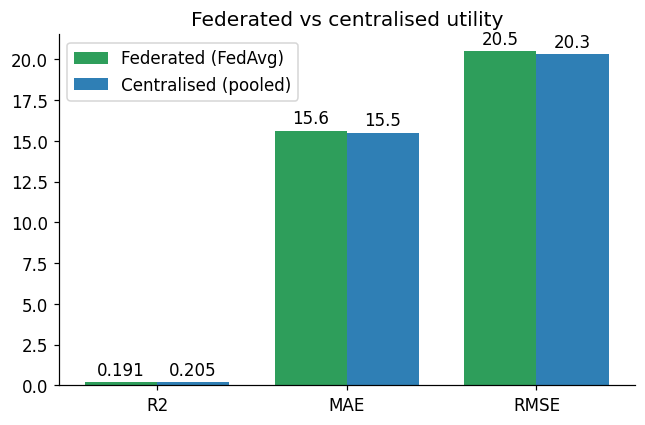

In [20]:
# --- Fig A: Federated vs centralised utility (R2, MAE, RMSE) ---
fed = hist_df.iloc[-1]
labels = ["R2", "MAE", "RMSE"]
fed_v = [fed["R2"], fed["MAE"], fed["RMSE"]]
x = np.arange(len(labels)); bw = 0.38
fig, ax = plt.subplots(figsize=(6, 4))
b1 = ax.bar(x - bw/2, fed_v, bw, label="Federated (FedAvg)", color=GREEN)
ax.bar_label(b1, fmt="%.3g", padding=2)
if cen is not None:
    cen_v = [cen["R2"], cen["MAE"], cen["RMSE"]]
    b2 = ax.bar(x + bw/2, cen_v, bw, label="Centralised (pooled)", color=BLUE)
    ax.bar_label(b2, fmt="%.3g", padding=2)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_title("Federated vs centralised utility"); ax.legend()
_save(fig, "fig_fed_vs_centralised"); plt.show()

saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_learning_curve.png


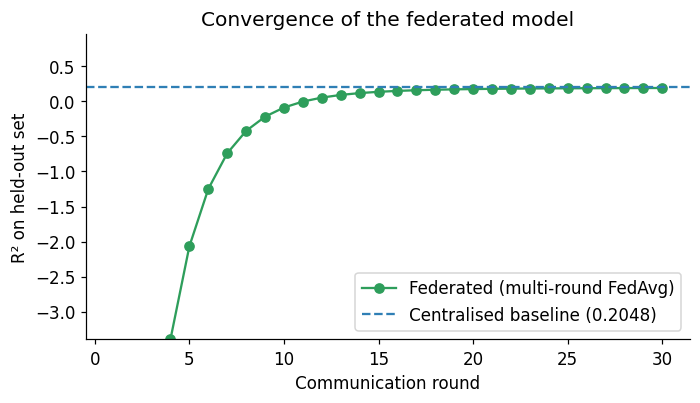

In [21]:
# --- Fig B: Learning curve (R2 vs communication round) ---
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.plot(hist_df["round"], hist_df["R2"], marker="o", color=GREEN, label="Federated (multi-round FedAvg)")
if cen is not None:
    ax.axhline(cen["R2"], color=BLUE, ls="--", label=f"Centralised baseline ({cen['R2']})")
ax.set_xlabel("Communication round"); ax.set_ylabel("R\u00b2 on held-out set")
ax.set_title("Convergence of the federated model")
ax.set_ylim(bottom=min(0, hist_df["R2"].iloc[3:].min())); ax.legend()
_save(fig, "fig_learning_curve"); plt.show()

per-participant R2 : median -0.132  IQR -0.539..0.013  min -4.393  max 0.460
per-participant MAE: median 15.70  IQR 13.14..19.38
saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_per_participant_distribution.png


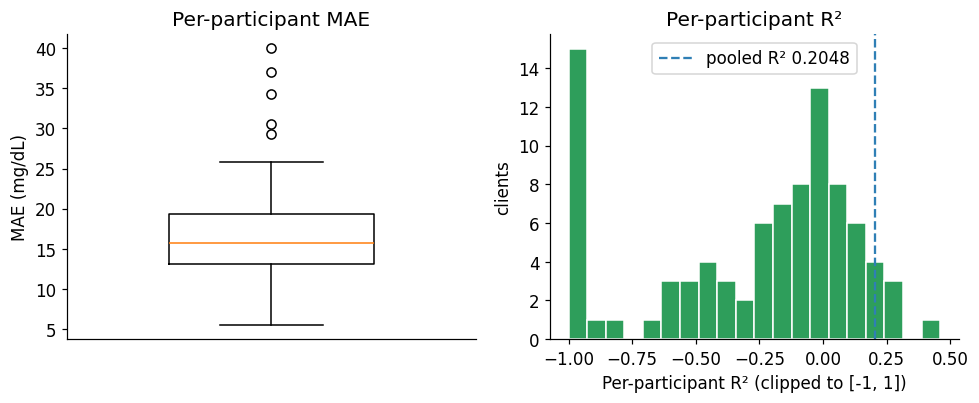

In [22]:
# --- Fig C: Per-participant R2 and MAE distribution (answers MR66) ---
per = []
for c in clients:
    yte = np.asarray(c["yte"], float)
    if len(yte) >= 2 and np.var(yte) > 0:
        yhat = fed_predict(c["Xte"])
        per.append({"r2": r2_score(yte, yhat), "mae": mean_absolute_error(yte, yhat), "n": len(yte)})
per = pd.DataFrame(per)
per.to_csv(REPORT_PATH / "per_participant_scores.csv", index=False)
print("per-participant R2 : median %.3f  IQR %.3f..%.3f  min %.3f  max %.3f"
      % (per.r2.median(), per.r2.quantile(.25), per.r2.quantile(.75), per.r2.min(), per.r2.max()))
print("per-participant MAE: median %.2f  IQR %.2f..%.2f"
      % (per.mae.median(), per.mae.quantile(.25), per.mae.quantile(.75)))

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ax[0].boxplot(per.mae, vert=True, widths=0.5)
ax[0].set_ylabel("MAE (mg/dL)"); ax[0].set_xticks([]); ax[0].set_title("Per-participant MAE")
ax[1].hist(per.r2.clip(-1, 1), bins=20, color=GREEN, edgecolor="white")
if cen is not None:
    ax[1].axvline(cen["R2"], color=BLUE, ls="--", label=f"pooled R\u00b2 {cen['R2']}"); ax[1].legend()
ax[1].set_xlabel("Per-participant R\u00b2 (clipped to [-1, 1])"); ax[1].set_ylabel("clients")
ax[1].set_title("Per-participant R\u00b2")
_save(fig, "fig_per_participant_distribution"); plt.show()

In [23]:
# --- Local-only baseline (L2-regularised, consistent with the report's models) ---
# Each client trains ONLY on its own data, no collaboration. Uses Ridge with the SAME
# L2 strength as the federated/centralised models, so the comparison is fair.
# Predictions pooled across clients for one held-out score. (RQ3 baseline.)
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

L2_ALPHA = 1e-4     # matches the report's lambda
lo_pred, lo_true, per_client_r2 = [], [], []
for c in clients:
    Xtr, ytr, Xte, yte = c["Xtr"], c["ytr"], c["Xte"], c["yte"]
    if len(ytr) < 2 or len(yte) < 1:
        continue
    sc = StandardScaler().fit(Xtr)                    # standardise on the client's OWN data
    m  = Ridge(alpha=L2_ALPHA).fit(sc.transform(Xtr), ytr)
    yh = m.predict(sc.transform(Xte))
    lo_pred.append(yh); lo_true.append(yte)
    if len(yte) >= 2 and np.var(yte) > 0:
        per_client_r2.append(r2_score(yte, yh))

lo_pred = np.concatenate(lo_pred); lo_true = np.concatenate(lo_true)
local_only = {"R2":  round(r2_score(lo_true, lo_pred), 4),
              "MAE": round(mean_absolute_error(lo_true, lo_pred), 3),
              "RMSE":round(mean_squared_error(lo_true, lo_pred)**0.5, 3)}
print("Local-only (per-client Ridge, alpha=%.0e):" % L2_ALPHA, local_only)
print("   per-client R2: median %.3f | mean %.3f | min %.3f | max %.3f"
      % (np.median(per_client_r2), np.mean(per_client_r2), np.min(per_client_r2), np.max(per_client_r2)))
_fed = 0.191
print("Federated (multi-round) R2 = %.3f -> federation %s local-only."
      % (_fed, "beats" if _fed > local_only["R2"] else "does NOT beat (local-only competitive)"))

Local-only (per-client Ridge, alpha=1e-04): {'R2': -0.9134, 'MAE': 14.31, 'RMSE': 31.534}
   per-client R2: median -0.234 | mean -4.359 | min -176.157 | max 1.000
Federated (multi-round) R2 = 0.191 -> federation beats local-only.


saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_pred_vs_actual.png


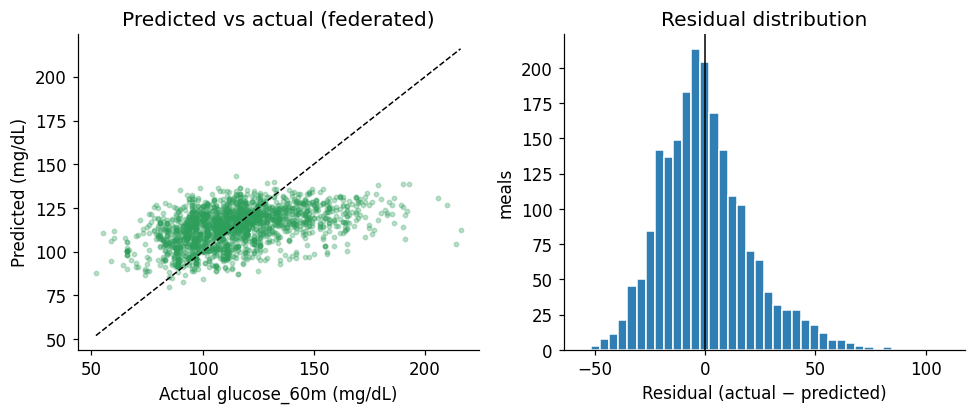

In [24]:
# --- Fig D: Predicted vs actual + residual distribution (pooled held-out) ---
Xte_raw = np.vstack([c["Xte"] for c in clients])
yte     = np.concatenate([c["yte"] for c in clients])
yhat    = fed_predict(Xte_raw); resid = yte - yhat
fig, ax = plt.subplots(1, 2, figsize=(9, 3.9))
ax[0].scatter(yte, yhat, s=8, alpha=0.3, color=GREEN)
lo, hi = min(yte.min(), yhat.min()), max(yte.max(), yhat.max())
ax[0].plot([lo, hi], [lo, hi], "k--", lw=1)
ax[0].set_xlabel("Actual glucose_60m (mg/dL)"); ax[0].set_ylabel("Predicted (mg/dL)")
ax[0].set_title("Predicted vs actual (federated)")
ax[1].hist(resid, bins=40, color=BLUE, edgecolor="white"); ax[1].axvline(0, color="k", lw=1)
ax[1].set_xlabel("Residual (actual \u2212 predicted)"); ax[1].set_ylabel("meals")
ax[1].set_title("Residual distribution")
_save(fig, "fig_pred_vs_actual"); plt.show()

saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_feature_coefficients.png


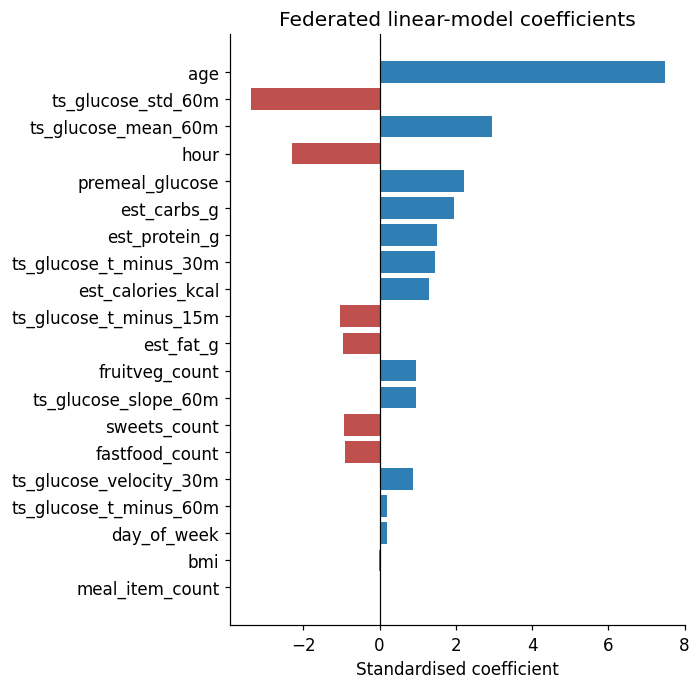

In [25]:
# --- Fig E: Federated linear-model coefficients (interpretability) ---
coef = np.array(global_model["coef"], float)
order = np.argsort(np.abs(coef))
fig, ax = plt.subplots(figsize=(6.5, max(4, 0.32 * len(FEATURES))))
cols = [BLUE if v >= 0 else RED for v in coef[order]]
ax.barh(np.array(FEATURES)[order], coef[order], color=cols)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Standardised coefficient"); ax.set_title("Federated linear-model coefficients")
_save(fig, "fig_feature_coefficients"); plt.show()

saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_recommendation_outcomes.png


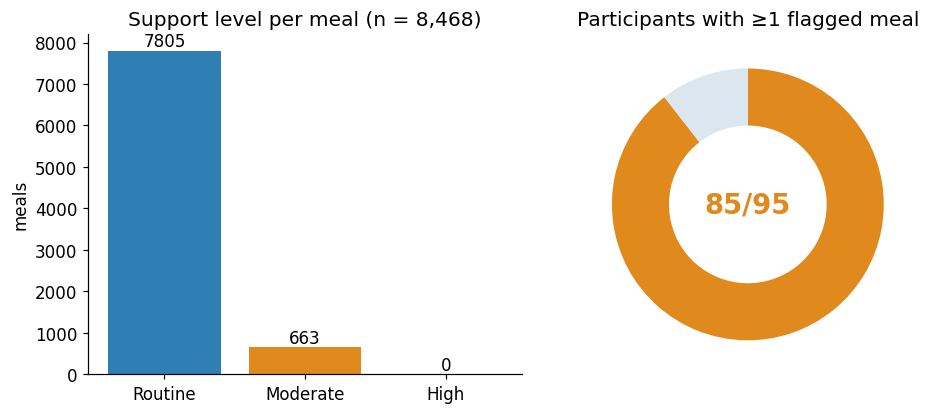

In [26]:
# --- Fig F: In-Pod recommendation outcomes (bar + donut) ---
tot = summary_df[["Routine", "Moderate", "High"]].sum()
n_clients = len(summary_df)
flagged = int(((summary_df["Moderate"] + summary_df["High"]) > 0).sum())
fig, ax = plt.subplots(1, 2, figsize=(9, 3.9))
bars = ax[0].bar(tot.index, tot.values, color=[BLUE, ORANGE, RED])
ax[0].bar_label(bars, fmt="%d"); ax[0].set_ylabel("meals")
ax[0].set_title(f"Support level per meal (n = {int(tot.sum()):,})")
ax[1].pie([flagged, n_clients - flagged], startangle=90, counterclock=False,
          colors=[ORANGE, "#dbe6ef"], wedgeprops=dict(width=0.42))
ax[1].text(0, 0, f"{flagged}/{n_clients}", ha="center", va="center",
           fontsize=18, color=ORANGE, fontweight="bold")
ax[1].set_title("Participants with \u22651 flagged meal")
_save(fig, "fig_recommendation_outcomes"); plt.show()

saved: C:\Users\Shabnam\Meal_Centric_Glucose_Dissertation\decentralised_solidpod_federated_workflow\reports\figures\fig_acv_outcomes.png


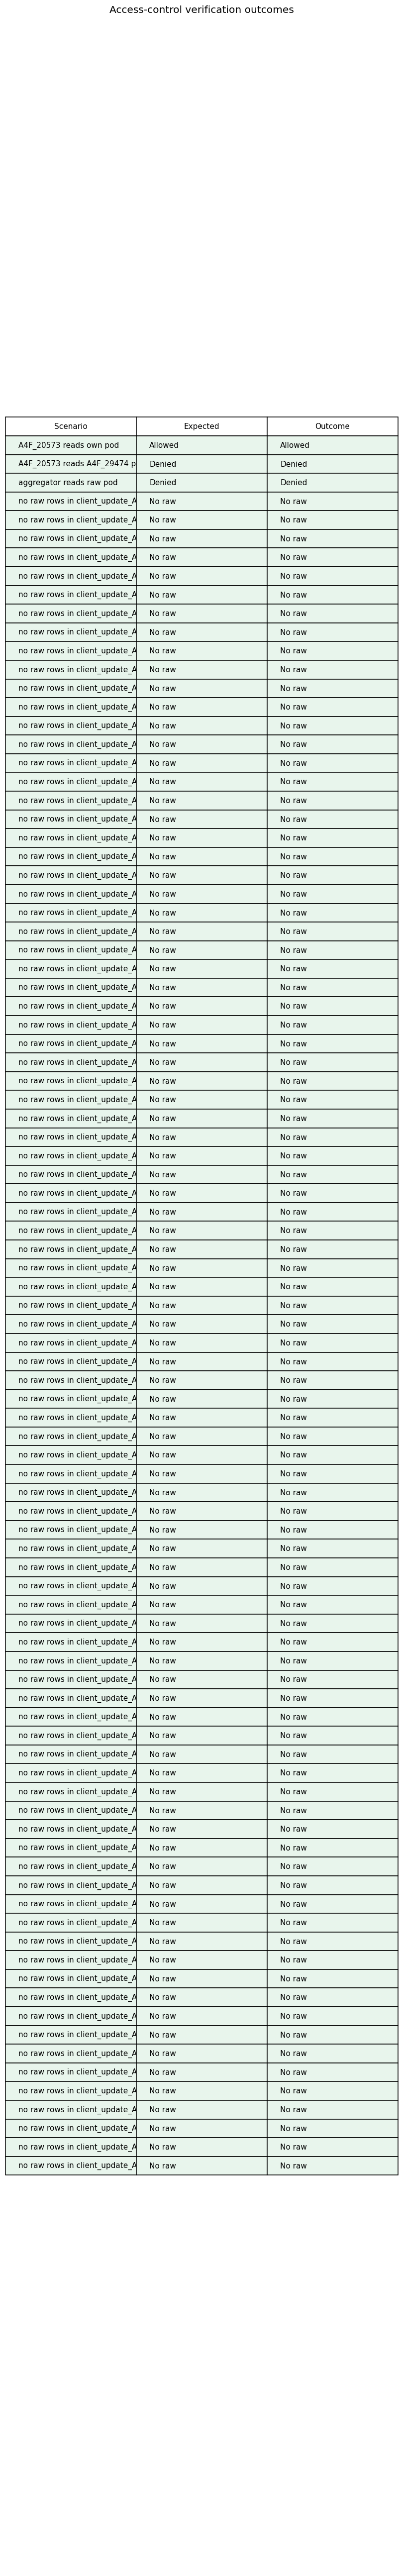

In [27]:
# --- Fig G: Access-control verification outcomes (from `checks`) ---
cdf = pd.DataFrame(checks)
show_cols = [c for c in ["test", "expected", "actual"] if c in cdf.columns]
fig, ax = plt.subplots(figsize=(7.5, 0.7 + 0.5 * len(cdf))); ax.axis("off")
tbl = ax.table(cellText=cdf[show_cols].values,
               colLabels=["Scenario", "Expected", "Outcome"],
               cellLoc="left", loc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.6)
for r in range(len(cdf)):
    ok = bool(cdf["passed"].iloc[r]) if "passed" in cdf.columns else True
    for col in range(len(show_cols)):
        tbl[(r + 1, col)].set_facecolor("#e8f5ec" if ok else "#fdecea")
ax.set_title("Access-control verification outcomes", pad=12)
_save(fig, "fig_acv_outcomes"); plt.show()